In [1]:
# ==========================================
# CELL 1: Imports and Setup
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ==========================================
# CELL 2: Load and Filter Dataset for Africa
# ==========================================
# Load the WHO dataset
df = pd.read_csv('Life Expectancy Data.csv')

# Clean column names (strip trailing/leading spaces)
df.columns = df.columns.str.strip()

# List of African countries present in the WHO dataset
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon',
    'Cape Verde', 'Central African Republic', 'Chad', 'Comoros', 'Congo', "Cote d'Ivoire",
    'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea',
    'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho',
    'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco',
    'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe',
    'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan',
    'Sudan', 'Swaziland', 'Togo', 'Tunisia', 'Uganda', 'United Republic of Tanzania',
    'Zambia', 'Zimbabwe'
]

# Subset for African nations
africa_df = df[df['Country'].isin(african_countries)].copy()

print(f"Total records in African dataset: {len(africa_df)}")
africa_df.head()

Total records in African dataset: 832


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
32,Algeria,2015,Developing,75.6,19.0,21,NaN,0.000000,95.0,63,...,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
33,Algeria,2014,Developing,75.4,11.0,21,0.01,54.237318,95.0,0,...,95.0,7.21,95.0,0.1,547.851700,39113313.0,6.0,5.8,0.741,14.4
34,Algeria,2013,Developing,75.3,112.0,21,0.53,544.450743,95.0,25,...,95.0,7.12,95.0,0.1,5471.866766,38338562.0,5.9,5.8,0.737,14.4
35,Algeria,2012,Developing,75.1,113.0,21,0.66,555.926083,95.0,18,...,95.0,6.14,95.0,0.1,5564.825660,37565847.0,5.9,5.8,0.732,14.4
36,Algeria,2011,Developing,74.9,116.0,21,0.56,509.002041,95.0,112,...,95.0,5.29,95.0,0.1,5432.252300,36819558.0,5.9,5.8,0.724,14.0


In [3]:
# ==========================================
# CELL 3: Data Cleaning & Feature Selection
# ==========================================
# Define key numeric features and target variable
features = ['Adult Mortality', 'infant deaths', 'BMI', 'GDP', 'Schooling']
target = 'Life expectancy'

# Extract subset with features and target
dataset = africa_df[features + [target]].copy()

# Handle missing values using median imputation
dataset.fillna(dataset.median(numeric_only=True), inplace=True)

# Features (X) and Target (y)
X = dataset[features]
y = dataset[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (832, 5)
Target shape: (832,)


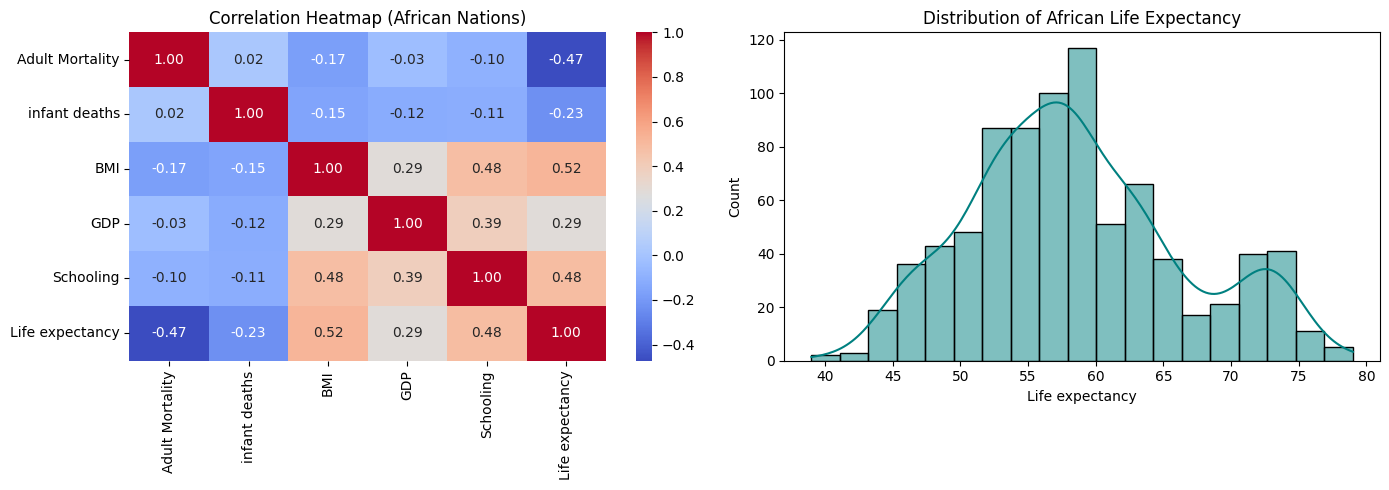

In [4]:
# ==========================================
# CELL 4: Exploratory Data Analysis & Visualizations
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Correlation Heatmap
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Heatmap (African Nations)")

# 2. Target Variable Distribution
sns.histplot(y, kde=True, color='teal', ax=axes[1])
axes[1].set_title("Distribution of African Life Expectancy")

plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# CELL 5: Train-Test Split and Standardization
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for inference in FastAPI
joblib.dump(scaler, 'scaler.joblib')
print("StandardScaler fitted and saved as scaler.joblib")

StandardScaler fitted and saved as scaler.joblib


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

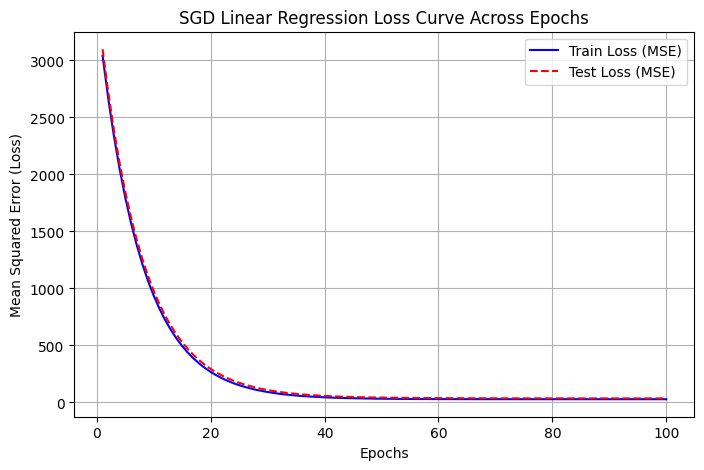

In [6]:
# ==========================================
# CELL 6: Gradient Descent Loss Curve (SGDRegressor)
# ==========================================
sgd = SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate='constant', eta0=0.0001, random_state=42)

train_errors, test_errors = [], []
epochs = 100

for epoch in range(epochs):
    sgd.fit(X_train_scaled, y_train)
    train_errors.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_errors.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

# Plot Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_errors, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, epochs + 1), test_errors, label='Test Loss (MSE)', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('SGD Linear Regression Loss Curve Across Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# ==========================================
# CELL 7: Model Comparison (OLS, SGD, Decision Tree, Random Forest)
# ==========================================
models = {
    "Ordinary Linear Regression": LinearRegression(),
    "Stochastic Gradient Descent (SGD)": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2 Score": r2}

results_df = pd.DataFrame(results).T
print("--- Model Performance Comparison ---")
print(results_df)

--- Model Performance Comparison ---
                                         MSE      RMSE       MAE  R2 Score
Ordinary Linear Regression         35.630791  5.969153  4.585234  0.447452
Stochastic Gradient Descent (SGD)  35.622307  5.968443  4.583504  0.447583
Decision Tree Regressor            10.707784  3.272275  2.130539  0.833948
Random Forest Regressor             6.936305  2.633687  1.789843  0.892435



Best Performing Model: Random Forest Regressor
Best model saved successfully as best_model.joblib


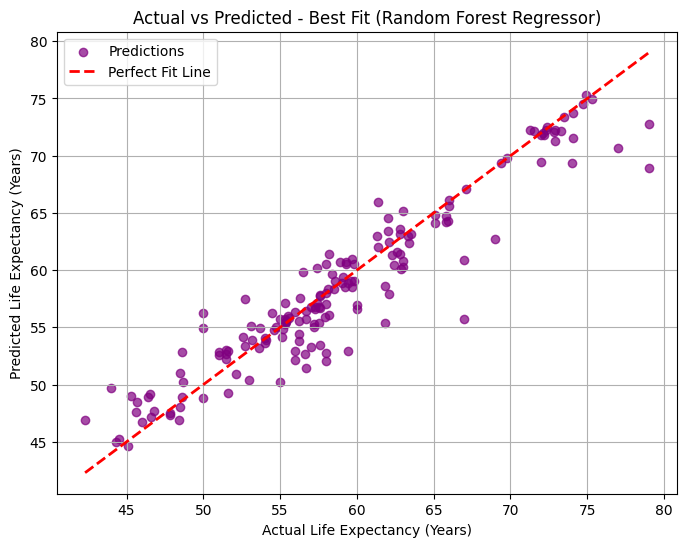

In [8]:
# ==========================================
# CELL 8: Save Best Model & Scatter Plot Fit Line
# ==========================================
# Best performing model selection based on lowest MSE
best_model_name = results_df['MSE'].idxmin()
best_model = models[best_model_name]

print(f"\nBest Performing Model: {best_model_name}")

# Save best model
joblib.dump(best_model, 'best_model.joblib')
print("Best model saved successfully as best_model.joblib")

# Scatter Plot: Actual vs Predicted (Line of Best Fit)
y_test_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_preds, alpha=0.7, color='purple', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel('Actual Life Expectancy (Years)')
plt.ylabel('Predicted Life Expectancy (Years)')
plt.title(f'Actual vs Predicted - Best Fit ({best_model_name})')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# ==========================================
# CELL 9: Single Data Point Prediction Test
# ==========================================
# Pick 1 row from test set
single_sample = X_test.iloc[[0]]
single_sample_scaled = scaler.transform(single_sample)

predicted_val = best_model.predict(single_sample_scaled)[0]
actual_val = y_test.iloc[0]

print("--- Single Data Point Inference Test ---")
print("Input Sample Data:")
print(single_sample)
print(f"\nPredicted Life Expectancy: {predicted_val:.2f} years")
print(f"Actual Life Expectancy:    {actual_val:.2f} years")

--- Single Data Point Inference Test ---
Input Sample Data:
      Adult Mortality  infant deaths   BMI         GDP  Schooling
2251            196.0             20  23.2  148.912351        8.7

Predicted Life Expectancy: 66.11 years
Actual Life Expectancy:    66.00 years
